# Evaluation on trained models
directly targeting publication production level images / results, decouple intermediate result/data with final plot, so style adjustment is easy

### Two Base models trained solely on real beam data validate on different syth data

data selection / distribution matching / Reverse Validation (used in Domain Adaptation)

In [1]:
from dirs import *
from train import *

c:\Users\qiyuanxu\Documents\GitHub\fiber-image-reconstruction-comparison


In [3]:
# ========================================
# load model for inference
# ========================================
import torch
from models.CAE import Autoencoder2D

model_name = "chromox_laser_vae_base_model"  # chromox_laser_vae_base_model  chromox_vae_base_model
model_path = dirs["models"][model_name] # should point to model.pth
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = Autoencoder2D.load_model(
    filepath=model_path,
    device=device,
    eval_mode=True, # inference mode
)
print(show_model_info(model))

Detected framework: PyTorch
Framework:           PyTorch
Model:               Autoencoder2D
Device / dtype:      unavailable / N/A
Parameters:          39,594,112 total
                     39,594,112 trainable
                     0 non-trainable
Size:                151.07 MB
Sub-modules:         67


Samples:  300 500
Batch:  10 16


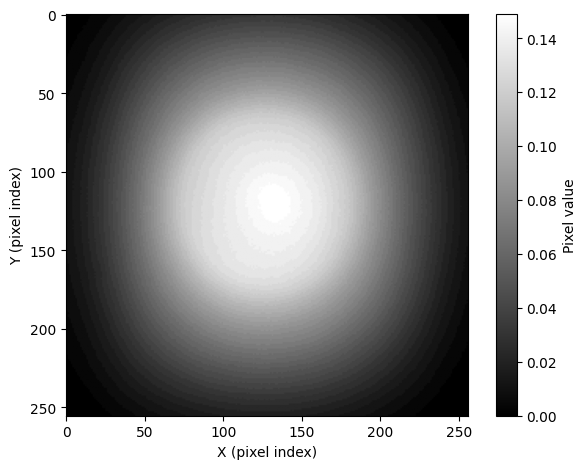

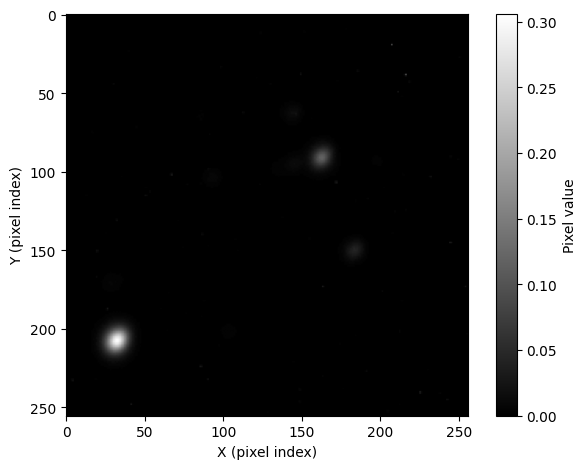

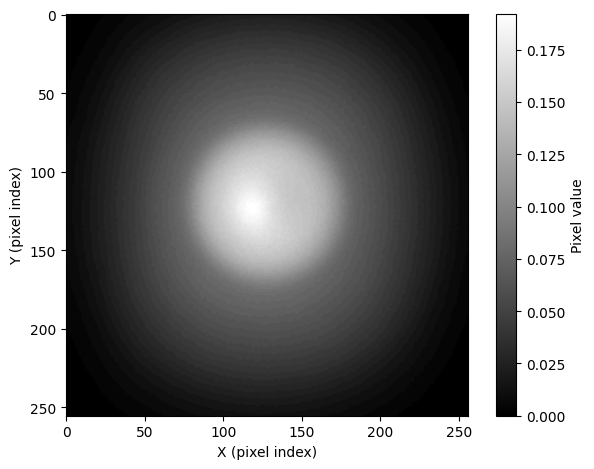

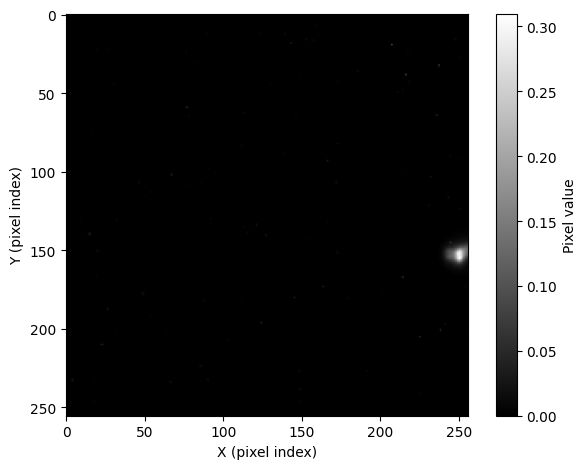

In [4]:
# ========================================
# load dataset for inference
# ========================================
from xflow.utils.visualization import plot_image

experiment_name = "CLEAR25"
dataset_sources = ["processed_chromox", "processed_chromox_laser"]  # ["processed_dmd", "processed_chromox", "processed_yag", "processed_chromox_laser", "processed_yag_laser"]

config_manager = ConfigManager(
    load_config(
        f"{experiment_name}.yaml",
        machine=detect_machine(),
        resolve=True,
    )
)
config = config_manager.get()

dataset_dirs = [resolve_dataset_dir(config, src) for src in dataset_sources]
db_rel = config["dataset_structure"]["db"].lstrip("/\\")
db_paths = [d / db_rel for d in dataset_dirs]

# multiple datasets (source).
eval_provider_1 = SqlProvider(
    sources={"connection": db_paths[0], "sql": config["sql"]["dmd_all"]}, output_config={'list': "image_path"}
).subsample(n_samples=300, seed=config["seed"])
eval_provider_2 = SqlProvider(
    sources={"connection": db_paths[1], "sql": config["sql"]["chromox_laser"]}, output_config={'list': "image_path"}
).subsample(n_samples=500, seed=config["seed"])

# pad abs path to db saved relative dirs.
for t in config["data"]["transforms"]["torch"]:
    if t.get("name") == "add_parent_dir":
        t.setdefault("params", {})["parent_dir"] = str(dataset_dirs[0])
        break

transforms_1 = build_transforms_from_config(config["data"]["transforms"]["torch"])

for t in config["data"]["transforms"]["torch"]:
    if t.get("name") == "add_parent_dir":
        t.setdefault("params", {})["parent_dir"] = str(dataset_dirs[1])
        break

transforms_2 = build_transforms_from_config(config["data"]["transforms"]["torch"])

# normally leave the pipelines decoupled and untouched so the output interface remains consistent.
eval_dataset_1 = PyTorchPipeline(
    eval_provider_1,
    transforms_1
).to_memory_dataset(config["data"]["dataset_ops"])

eval_dataset_2 = PyTorchPipeline(
    eval_provider_2,
    transforms_2
).to_memory_dataset(config["data"]["dataset_ops"])   # testset data do not need thresholding since it is to remove stacking noise?

print("Samples: ", len(eval_provider_1), len(eval_provider_2))
print("Batch: ", len(eval_dataset_1), len(eval_dataset_2))

plot_image(next(iter(eval_dataset_1))[0])
plot_image(next(iter(eval_dataset_1))[1])
plot_image(next(iter(eval_dataset_2))[0])
plot_image(next(iter(eval_dataset_2))[1])

In [5]:
import os
import matplotlib.pyplot as plt
import torch
from tqdm import tqdm

model.eval()
save_dir = dirs["save"]["model_inference"][model_name]
os.makedirs(save_dir, exist_ok=True)

saved = 0

for batch in tqdm(eval_dataset_1):  
    if len(batch) == 3:
        x, _, y_true = batch
    else:
        x, y_true = batch

    with torch.inference_mode():
        y_pred = model(x.to(device)).cpu()

    x = x.cpu()
    y_true = y_true.cpu()

    if x.ndim == 3:
        x = x.unsqueeze(0)
        y_true = y_true.unsqueeze(0)
        y_pred = y_pred.unsqueeze(0)

    for i in range(x.shape[0]):
        fig, axes = plt.subplots(1, 3, figsize=(9, 3))

        axes[0].imshow(x[i].squeeze().numpy(), cmap="viridis")
        axes[0].set_title("input fiber speckle")
        axes[0].axis("off")

        axes[1].imshow(y_true[i].squeeze().numpy(), cmap="viridis")
        axes[1].set_title("ground truth (original image)")
        axes[1].axis("off")

        axes[2].imshow(y_pred[i].squeeze().numpy(), cmap="viridis")
        axes[2].set_title("reconstructed image")
        axes[2].axis("off")

        out_path = os.path.join(save_dir, f"inference_{saved:05d}.png")
        fig.tight_layout()
        fig.savefig(out_path, dpi=80)
        plt.close(fig)

        saved += 1

print("saved:", saved, "images to", save_dir)

100%|██████████| 10/10 [02:02<00:00, 12.24s/it]

saved: 300 images to C:/Users/qiyuanxu/Desktop/Scope 1 cross field/Model_trained_on_CHROMOX_LASER_only/inference/
